In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.chdir(r"C:\Lucky\CliniScan\B13-CliniScan")

from ultralytics import YOLO

print("✅ Ultralytics imported")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\sonil\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics imported


In [2]:
# YOLOv8 small model load karo
model = YOLO('yolov8s.pt')

# Train karo
results = model.train(
    data="data/yolo_dataset/dataset.yaml",
    epochs=10,
    imgsz=224,
    batch=16,
    patience=5,
    device='cpu',
    project="data/yolo_runs",
    name="cliniscan_detection",
    exist_ok=True
)

print("✅ Training Complete!")

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.13.9 torch-2.10.0+cpu CPU (AMD Ryzen 7 PRO 5850U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

In [3]:
metrics = model.val()
print("\n✅ Validation Results:")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.14  Python-3.13.9 torch-2.10.0+cpu CPU (AMD Ryzen 7 PRO 5850U with Radeon Graphics)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 165.040.6 MB/s, size: 29.6 KB)
val: Scanning C:\Lucky\CliniScan\B13-CliniScan\data\yolo_dataset\val\labels.cache... 1001 images, 720 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1001/1001 209.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.0it/s 31.2s0.5ss
                   all       1001       2217      0.445      0.184      0.162     0.0741
    Aortic enlargement        203        474      0.464      0.565      0.551      0.262
           Atelectasis         13         23          1          0      0.132     0.0402
         Calcification         31         58          1          0   0.000644   0.000129
          Cardiomegaly        143        339      0.452       0.64      0.585   

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.chdir(r"C:\Lucky\CliniScan\B13-CliniScan")

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import random

# Best model load karo
model = YOLO("runs/detect/data/yolo_runs/cliniscan_detection/weights/best.pt")

# Val images se 20 random images lo
val_img_dir = "data/yolo_dataset/val/images"
all_val_imgs = [f for f in os.listdir(val_img_dir) if f.endswith('.png')]
random.seed(42)
sample_imgs = random.sample(all_val_imgs, 20)

# Output folder banao
os.makedirs("data/detection_results", exist_ok=True)

CLASS_NAMES = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity',
    'Nodule/Mass', 'Other lesion', 'Pleural effusion',
    'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis'
]

COLORS = [
    (255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),
    (0,255,255),(128,0,0),(0,128,0),(0,0,128),(128,128,0),
    (128,0,128),(0,128,128),(64,0,0),(0,64,0)
]

print("Generating visualizations...")
for img_name in sample_imgs:
    img_path = os.path.join(val_img_dir, img_name)
    
    # Predict karo
    results = model.predict(img_path, conf=0.25, verbose=False)
    
    # Image load karo
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Boxes draw karo
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        color = COLORS[cls_id % len(COLORS)]
        
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        label = f"{CLASS_NAMES[cls_id]} {conf:.2f}"
        cv2.putText(img, label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    
    # Save karo
    save_path = f"data/detection_results/{img_name}"
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

print(f"✅ Saved 20 visualizations to data/detection_results/")

Generating visualizations...
✅ Saved 20 visualizations to data/detection_results/


In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.chdir(r"C:\Lucky\CliniScan\B13-CliniScan")
os.makedirs("data/detection_results", exist_ok=True)

import pandas as pd

results_data = {
    'Class': [
        'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
        'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity',
        'Nodule/Mass', 'Other lesion', 'Pleural effusion',
        'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis', 'ALL'
    ],
    'Images': [203,13,31,143,24,34,38,83,54,66,61,122,4,94,1001],
    'Instances': [474,23,58,339,33,102,67,154,145,138,150,278,8,248,2217],
    'Precision': [0.464,1.0,1.0,0.452,0.311,0.309,0.466,0.164,0.0,0.506,0.221,0.151,1.0,0.184,0.445],
    'Recall': [0.565,0.0,0.0,0.64,0.121,0.245,0.149,0.143,0.0,0.0507,0.447,0.108,0.0,0.105,0.184],
    'mAP50': [0.551,0.132,0.000644,0.585,0.0771,0.198,0.153,0.0908,0.00794,0.0423,0.289,0.0549,0.0047,0.076,0.162],
    'mAP50-95': [0.262,0.0402,0.000129,0.364,0.0272,0.0814,0.0618,0.0315,0.00314,0.0121,0.112,0.0133,0.00121,0.0267,0.0741]
}

results_df = pd.DataFrame(results_data)
results_df.to_csv("data/detection_results/map_results_table.csv", index=False)

print("✅ Results table saved!")
print("\n" + "="*60)
print("DETECTION MODEL — RESULTS SUMMARY")
print("="*60)
print(f"Overall mAP50:    0.162")
print(f"Overall mAP50-95: 0.074")
print(f"Precision:        0.445")
print(f"Recall:           0.184")
print("="*60)
print("\nTop performing classes:")
top = results_df[results_df['Class'] != 'ALL'].nlargest(3, 'mAP50')[['Class','mAP50','mAP50-95']]
print(top.to_string(index=False))

✅ Results table saved!

DETECTION MODEL — RESULTS SUMMARY
Overall mAP50:    0.162
Overall mAP50-95: 0.074
Precision:        0.445
Recall:           0.184

Top performing classes:
             Class  mAP50  mAP50-95
      Cardiomegaly  0.585     0.364
Aortic enlargement  0.551     0.262
  Pleural effusion  0.289     0.112


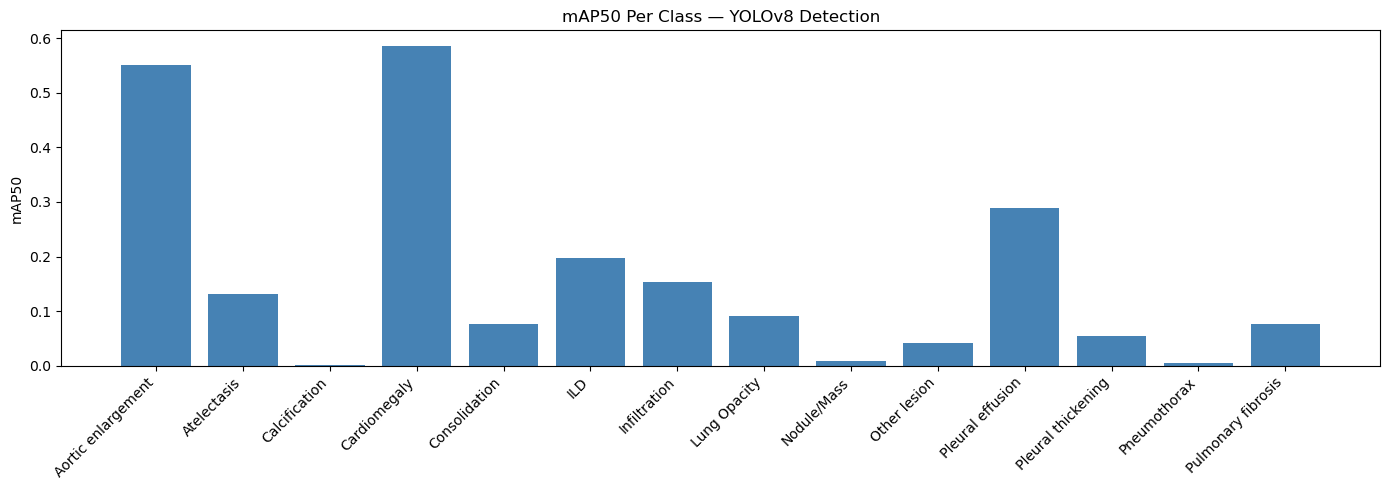

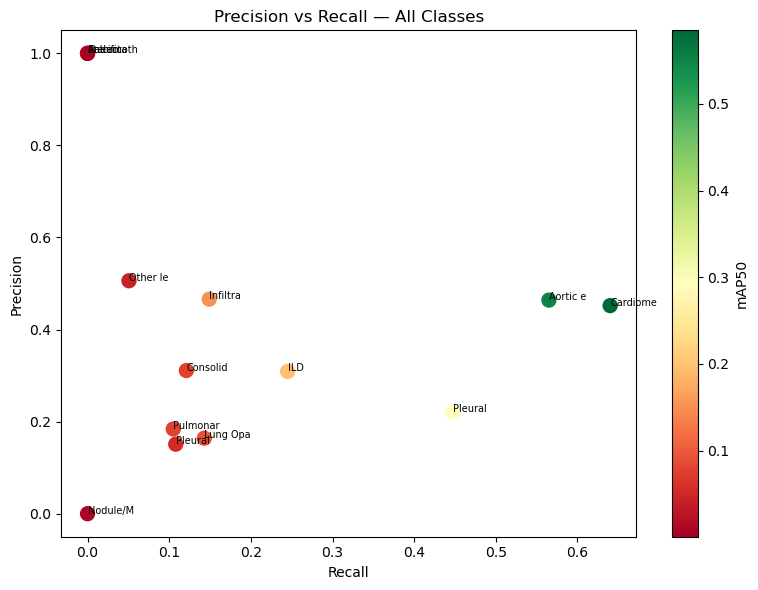

✅ Plots saved!


In [3]:
import matplotlib.pyplot as plt
import numpy as np

classes = results_df[results_df['Class'] != 'ALL']['Class'].values
precisions = results_df[results_df['Class'] != 'ALL']['Precision'].values
recalls = results_df[results_df['Class'] != 'ALL']['Recall'].values
map50s = results_df[results_df['Class'] != 'ALL']['mAP50'].values

# Plot 1 — mAP50 per class
plt.figure(figsize=(14, 5))
bars = plt.bar(classes, map50s, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("mAP50 Per Class — YOLOv8 Detection")
plt.ylabel("mAP50")
plt.tight_layout()
plt.savefig("data/detection_results/map50_per_class.png")
plt.show()

# Plot 2 — Precision vs Recall
plt.figure(figsize=(8, 6))
plt.scatter(recalls, precisions, c=map50s, cmap='RdYlGn', s=100)
for i, cls in enumerate(classes):
    plt.annotate(cls[:8], (recalls[i], precisions[i]),
                fontsize=7, ha='left')
plt.colorbar(label='mAP50')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall — All Classes")
plt.tight_layout()
plt.savefig("data/detection_results/precision_recall_plot.png")
plt.show()

print("✅ Plots saved!")